In [1]:
import sys
import importlib
sys.path.insert(0, '/lustre/lrspec/users/4301/hxe-for-tda/hxetda')
import hxetda
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support
from sklearn.utils import class_weight

sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_ABC-SN/")
from plot_data import *


# Notebook from the HXE no change

In [2]:
# Let's import preprocess our variable star data
scaler = StandardScaler()

# I am adding some conversions here for events which are either "candidates" or have <5 objects
conversions = {'SN Ia-91T-like':'SN Ia-91T', 'SN IIn-pec':'SN IIn', 'TDE-H-He':'TDE', 'SN IIP':'SN II', 
               'SN IIL': 'SN II', 'SN Iax[02cx-like]': 'SN Iax'}
#'SN I': 'SN Ia'
def make_dataset(load=False):
    # to do - eventually, I do want to save/load a dataset...
    if not load:
        metadata, all_labels = np.loadtxt('/lustre/lrspec/users/4301/hxe-for-tda/data/training_set_dynesty.csv',usecols=(0,1), 
                                          delimiter=',', skiprows=1, dtype=str, unpack=True)
        

        gind = np.where((all_labels !='Galaxy') & (all_labels !='Other') &  (all_labels !='M dwarf') & (all_labels !='SN I'))

        metadata = metadata[gind]
        all_labels = all_labels[gind]
        all_dat = np.zeros((len(all_labels),15))
        
        for key in conversions:
            gind = np.where(all_labels == key)
            all_labels[gind] = conversions[key]
        vertices = np.asarray(np.unique(all_labels),dtype=str)
        print(np.unique(all_labels, return_counts=True))
        vertices = np.append(vertices, ['StellarTransient', 'SN-like', 'ILOT', 'CC'])
        vertices = np.insert(vertices, 0, 'Object')

        print(metadata)

        for i, md in enumerate(metadata):
            # print(md)
            one_sn_data = np.load('/lustre/lrspec/users/4301/hxe-for-tda/data/dynesty_fits/'+md+'_eqwt_dynesty.npz')
            all_dat[i] = np.mean(one_sn_data['arr_0'],axis=0)
        return(all_labels,all_dat, vertices)

labels,all_features, vertices = make_dataset()
scaler.fit(all_features)
all_features = scaler.transform(all_features)

(array(['AGN', 'CV', 'ILRT', 'LBV', 'LRN', 'Nova', 'QSO', 'SLSN-I',
       'SLSN-II', 'SN', 'SN II', 'SN II-pec', 'SN IIb', 'SN IIn', 'SN Ia',
       'SN Ia-91T', 'SN Ia-91bg-like', 'SN Ia-CSM', 'SN Ia-SC',
       'SN Ia-pec', 'SN Iax', 'SN Ib', 'SN Ib-pec', 'SN Ib/c', 'SN Ibn',
       'SN Ic', 'SN Ic-BL', 'SN Ic-Ca-rich', 'SN Ic-pec', 'SN Icn', 'TDE',
       'Varstar'], dtype='<U17'), array([  47,  103,    1,    7,    1,   14,    4,   89,   49,   11,  957,
          4,   58,  196, 4173,  157,   24,   15,    3,   32,   12,   82,
          3,   14,   18,   92,   49,    1,    1,    2,   51,    8]))
['ZTF23aaitimz' 'ZTF23aaikcdx' 'ZTF23aaicagr' ... 'ZTF23aacdnjz'
 'ZTF23aacjeou' 'ZTF23aaetmwj']


In [3]:
# Tell me a little about the data...
ulab, counts = np.unique(labels, return_counts=True)
for x,y in zip(ulab, counts):
    print(x,y, y/np.sum(counts))
print('Features',np.shape(all_features))

AGN 47 0.007486460656259956
CV 103 0.01640649888499522
ILRT 1 0.00015928639694170118
LBV 7 0.0011150047785919083
LRN 1 0.00015928639694170118
Nova 14 0.0022300095571838167
QSO 4 0.0006371455877668047
SLSN-I 89 0.014176489327811405
SLSN-II 49 0.007805033450143358
SN 11 0.001752150366358713
SN II 957 0.15243708187320804
SN II-pec 4 0.0006371455877668047
SN IIb 58 0.009238611022618668
SN IIn 196 0.03122013380057343
SN Ia 4173 0.664702134437719
SN Ia-91T 157 0.025007964319847083
SN Ia-91bg-like 24 0.003822873526600828
SN Ia-CSM 15 0.002389295954125518
SN Ia-SC 3 0.0004778591908251035
SN Ia-pec 32 0.005097164702134438
SN Iax 12 0.001911436763300414
SN Ib 82 0.013061484549219496
SN Ib-pec 3 0.0004778591908251035
SN Ib/c 14 0.0022300095571838167
SN Ibn 18 0.002867155144950621
SN Ic 92 0.014654348518636508
SN Ic-BL 49 0.007805033450143358
SN Ic-Ca-rich 1 0.00015928639694170118
SN Ic-pec 1 0.00015928639694170118
SN Icn 2 0.00031857279388340236
TDE 51 0.00812360624402676
Varstar 8 0.001274291175

['Object' 'AGN' 'CV' 'ILRT' 'LBV' 'LRN' 'Nova' 'QSO' 'SLSN-I' 'SLSN-II'
 'SN' 'SN II' 'SN II-pec' 'SN IIb' 'SN IIn' 'SN Ia' 'SN Ia-91T'
 'SN Ia-91bg-like' 'SN Ia-CSM' 'SN Ia-SC' 'SN Ia-pec' 'SN Iax' 'SN Ib'
 'SN Ib-pec' 'SN Ib/c' 'SN Ibn' 'SN Ic' 'SN Ic-BL' 'SN Ic-Ca-rich'
 'SN Ic-pec' 'SN Icn' 'TDE' 'Varstar' 'StellarTransient' 'SN-like' 'ILOT'
 'CC']


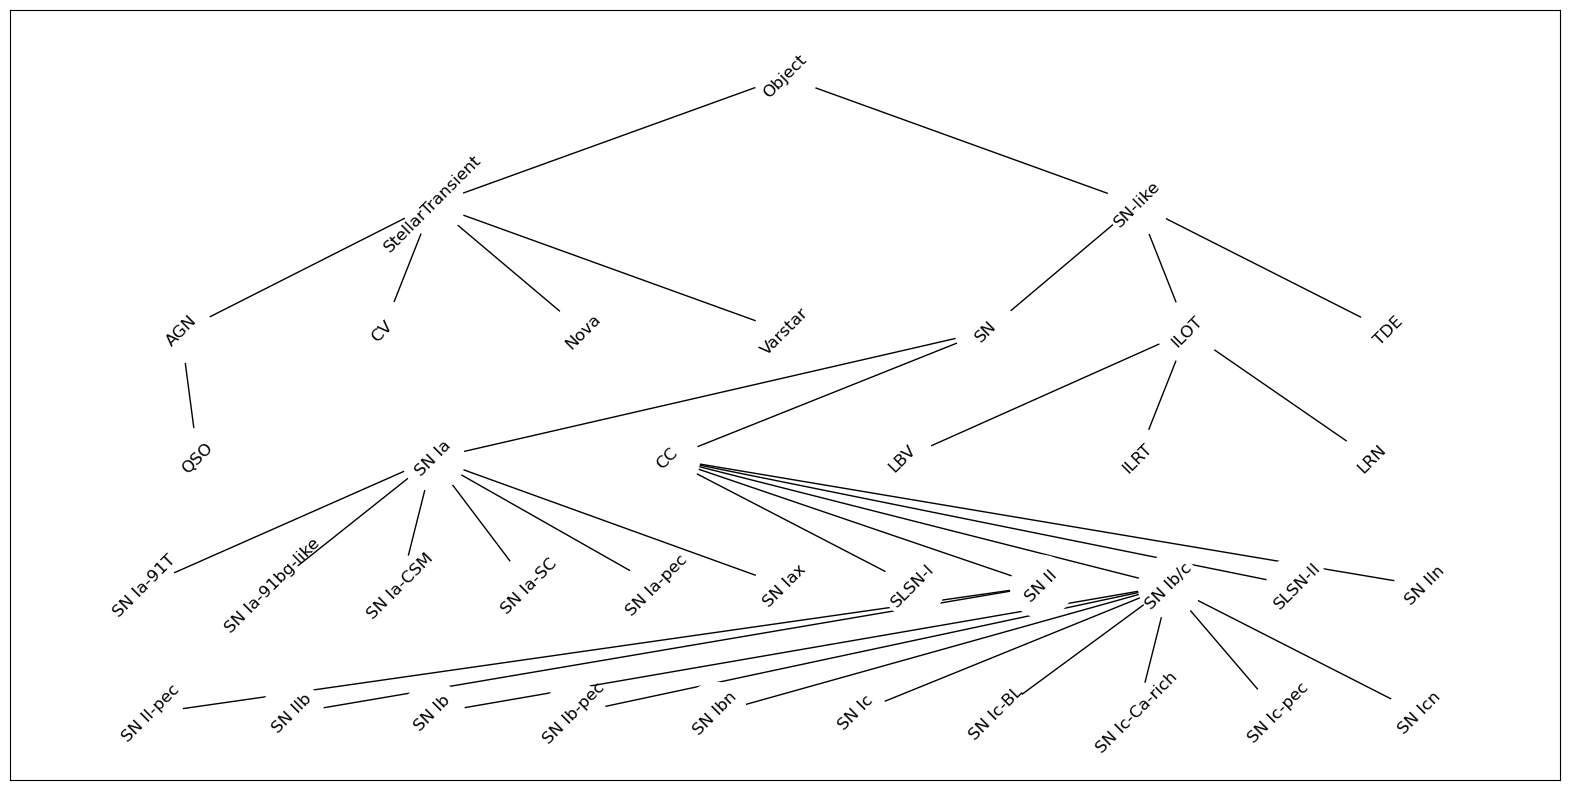

In [4]:
# Make a graph

print(vertices)
G=nx.DiGraph()

G.add_edge('Object','StellarTransient') #this does NOT include extragalactic transients
G.add_edge('Object','SN-like')


G.add_edge('StellarTransient','AGN')
G.add_edge('AGN','QSO')

G.add_edge('StellarTransient', 'CV')
G.add_edge('StellarTransient', 'Nova')
G.add_edge('StellarTransient', 'Varstar')

G.add_edge('SN-like', 'SN')
G.add_edge('SN-like', 'ILOT')
G.add_edge('ILOT', 'LBV')
G.add_edge('ILOT', 'ILRT')
G.add_edge('ILOT', 'LRN')
G.add_edge('SN-like', 'TDE')


G.add_edge('SN', 'SN Ia')
G.add_edge('SN Ia', 'SN Ia-91T')
G.add_edge('SN Ia', 'SN Ia-91bg-like')
G.add_edge('SN Ia', 'SN Ia-CSM')
G.add_edge('SN Ia', 'SN Ia-SC')
G.add_edge('SN Ia', 'SN Ia-pec')
G.add_edge('SN Ia', 'SN Iax')


G.add_edge('SN', 'CC')

G.add_edge('CC', 'SLSN-I')
G.add_edge('CC', 'SN II')

G.add_edge('CC', 'SN Ib/c')
G.add_edge('SN Ib/c', 'SN Ib')
G.add_edge('SN Ib/c', 'SN Ib-pec')
G.add_edge('SN Ib/c', 'SN Ibn')
G.add_edge('SN Ib/c', 'SN Ic')
G.add_edge('SN Ib/c', 'SN Ic-BL')
G.add_edge('SN Ib/c', 'SN Ic-Ca-rich')
G.add_edge('SN Ib/c', 'SN Ic-pec')
G.add_edge('SN Ib/c', 'SN Icn')

G.add_edge('CC', 'SLSN-II')
G.add_edge('SN II', 'SN II-pec')
G.add_edge('SN II', 'SN IIb')
G.add_edge('CC', 'SN IIn')

importlib.reload(hxetda)
pos = hxetda.hierarchy_pos(G, 'Object')

fig = plt.figure(1, figsize=(20, 10))

nx.draw_networkx(G, pos=pos, nodelist=vertices, node_color='white', with_labels=False, node_size=2000, arrows=False)
text = nx.draw_networkx_labels(G, pos)
for _, t in text.items():
    t.set_rotation(45) 

plt.show()

In [5]:
# Some pre-processing for the graph
importlib.reload(hxetda)
paths, pathlengths, mask_list, y_dict = hxetda.calc_path_and_mask(G, vertices, 'Object')

In [6]:
# Some pre-processing for the class weights

class_weight_dict = hxetda.calc_class_weights(labels, vertices, paths)
print(class_weight_dict)

{np.str_('AGN'): array([3.84681373]), np.str_('CV'): array([1.90473301]), np.str_('ILRT'): array([196.1875]), np.str_('LBV'): array([28.02678571]), np.str_('LRN'): array([196.1875]), np.str_('Nova'): array([14.01339286]), np.str_('QSO'): array([49.046875]), np.str_('SLSN-I'): array([2.20435393]), np.str_('SLSN-II'): array([4.00382653]), np.str_('SN'): array([0.03247062]), np.str_('SN II'): array([0.19252944]), np.str_('SN II-pec'): array([49.046875]), np.str_('SN IIb'): array([3.3825431]), np.str_('SN IIn'): array([1.00095663]), np.str_('SN Ia'): array([0.04442652]), np.str_('SN Ia-91T'): array([1.24960191]), np.str_('SN Ia-91bg-like'): array([8.17447917]), np.str_('SN Ia-CSM'): array([13.07916667]), np.str_('SN Ia-SC'): array([65.39583333]), np.str_('SN Ia-pec'): array([6.13085938]), np.str_('SN Iax'): array([16.34895833]), np.str_('SN Ib'): array([2.39253049]), np.str_('SN Ib-pec'): array([65.39583333]), np.str_('SN Ib/c'): array([0.74880725]), np.str_('SN Ibn'): array([10.89930556])

In [7]:
# Set up for train test split...
labels_new = [y_dict[x] for x in labels]
weights = [class_weight_dict[x] for x in labels]
X_train, X_test, y_train, y_test, labels_train, labels_test, weights_train, weights_test = train_test_split(all_features, labels_new, labels, weights,
                                                                                                            test_size=0.33, random_state = 7)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

weights_train = torch.tensor(weights_train, dtype=torch.float32)
weights_test = torch.tensor(weights_test, dtype=torch.float32)

print(np.shape(X_train))

torch.Size([4206, 15])


/tmp/ipykernel_25084/1487783298.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  y_train = torch.tensor(y_train, dtype=torch.float32)


4206
1 -0.10669984 -0.15113315
11 -0.4898458 -0.53951454
21 -0.51401794 -0.56111866
31 -0.5499891 -0.6043182
41 -0.59648675 -0.65711504
51 -0.6293457 -0.6833858
61 -0.6598279 -0.7012408
71 -0.6860974 -0.71479166
81 -0.7061039 -0.7250871
91 -0.7217672 -0.7320085
101 -0.7337409 -0.7366406
111 -0.74289757 -0.74001026
121 -0.75123096 -0.74256814
131 -0.75878197 -0.744815
141 -0.7660952 -0.7469789
151 -0.7738866 -0.74882454
161 -0.7810019 -0.7503197
171 -0.78841573 -0.75157034
181 -0.7959611 -0.7526202
191 -0.801752 -0.75371504
201 -0.8060553 -0.75484854
211 -0.8095435 -0.75594926
221 -0.8125684 -0.7570313
231 -0.8153642 -0.7581249
241 -0.8180974 -0.75922525
251 -0.82088333 -0.760212
261 -0.82380986 -0.760955
271 -0.8268965 -0.76146173
281 -0.830057 -0.7618029
291 -0.83319217 -0.76201814
301 -0.83645797 -0.76204085
311 -0.84043705 -0.76171356
321 -0.84473866 -0.7612436
331 -0.8485256 -0.76069945
341 -0.852023 -0.7600069
351 -0.8552454 -0.75918466
361 -0.8582171 -0.75830346
371 -0.86105317 -

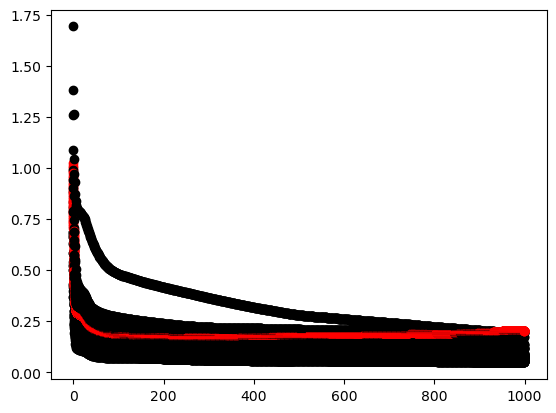

In [8]:
# Train!

model = hxetda.Feedforward(np.shape(X_test[0])[0],15, len(vertices))
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.001)
model.train()
epoch = 1000
n_batches = 128
loss=torch.tensor(0)
print(len(X_train))
for epoch in range(epoch):
	if epoch%10==1:
		print(epoch, np.log10(loss.detach().numpy()), np.log10(loss2.detach().numpy()))
	for i in range(int(len(X_train)/n_batches)+1):
		# Local batches and labels
		local_X, local_y, local_weights = X_train[i*n_batches:(i+1)*n_batches,], y_train[i*n_batches:(i+1)*n_batches,], weights_train[i*n_batches:(i+1)*n_batches,]
		optimizer.zero_grad()
		# Forward pass
		y_pred = model(local_X)
		# Compute Loss
		loss = hxetda.custom_hier_loss(y_pred.to(torch.float),local_y.to(torch.float), local_weights, mask_list, pathlengths)
		# Backward pass
		loss.backward()
		optimizer.step()
		plt.plot(epoch,loss.detach().numpy(),'ko')
		ypred2 = model(X_test)
		loss2 = hxetda.custom_hier_loss(ypred2.to(torch.float),y_test.to(torch.float), weights_test, mask_list, pathlengths)
		plt.plot(epoch,loss2.detach().numpy(),'ro')
	
#scheduler.step()

plt.show()

In [9]:
model.eval()
y_pred = model(X_test)


31


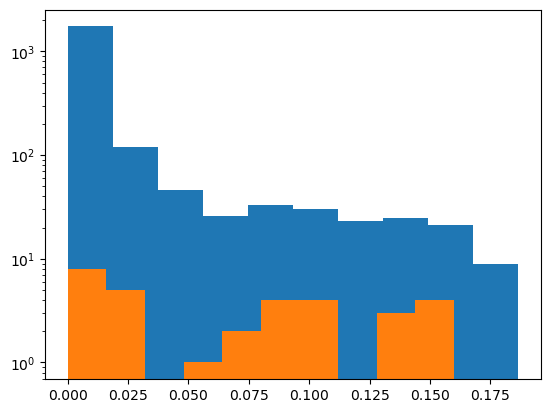

In [10]:
#Play around with different classes
specific_class = 'SN Ib'
single_class_prob = hxetda.get_prob(y_pred,specific_class, paths, vertices, mask_list).detach().numpy()
plt.hist(single_class_prob)
plt.yscale('log')

gind = np.where(single_class_prob>0.1)
# print(labels_test[gind])
gind2 = np.where(labels_test == specific_class)
plt.hist(single_class_prob[gind2])
print(len(gind2[0]))


# 5-way task

/tmp/ipykernel_25084/3637076730.py:19: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]


1865
['SN Ia' 'SN Ib/c' 'SN II' 'SLSN-I' 'SN IIn']
SN Ia [0.11202928 0.02678824 0.69498336 0.00340542 0.14797597]
(0.5484965172334213, 0.4373974196317342, 0.45659494513341875, None)
(0.8482573726541555, 0.8482573726541555, 0.8482573726541555, None)


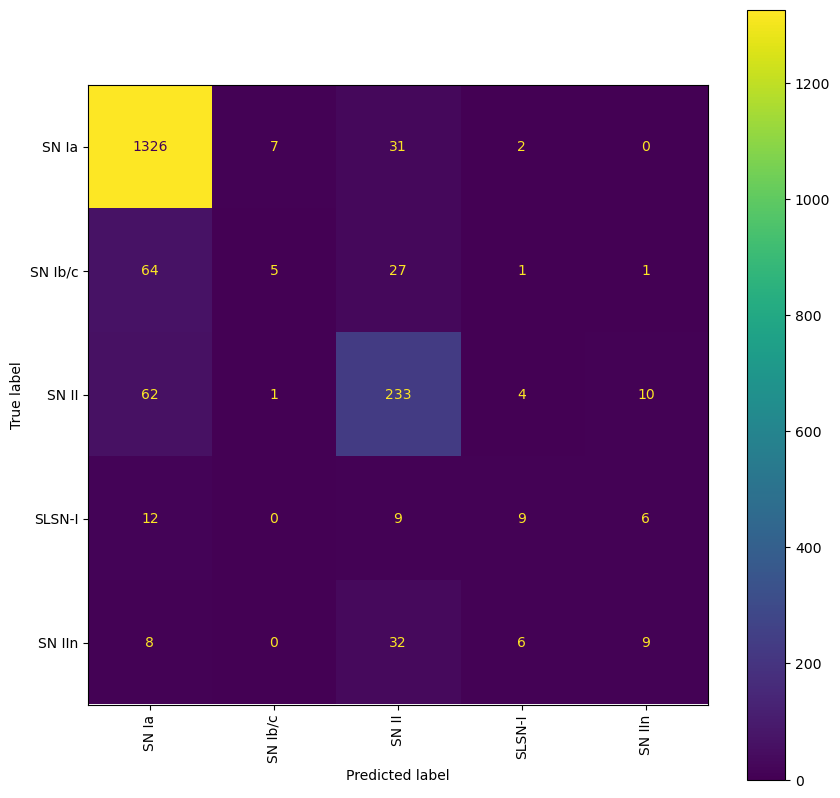

In [11]:
# 5-way task...
# Get my leaves...
importlib.reload(hxetda)

leaves = np.asarray(['SN Ia','SN Ib/c', 'SN II', 'SLSN-I', 'SN IIn'], dtype=str)
probs_list = np.zeros((len(y_pred), len(leaves)))
for i,leaf in enumerate(leaves):
    probs_list[:,i] = hxetda.get_prob(y_pred,leaf, paths, vertices, mask_list).detach().numpy()

my_predicted_types = leaves[np.argmax(probs_list,axis=1)]

fiveleaf_labels_test = np.copy(labels_test)

for i,s in enumerate(fiveleaf_labels_test):
    is_Ibc = hxetda.is_parent(s, 'SN Ib/c', vertices, paths)
    if is_Ibc:
        fiveleaf_labels_test[i] = 'SN Ib/c'

gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]
cm = confusion_matrix(fiveleaf_labels_test[gind], my_predicted_types[gind], labels=leaves)
disp = ConfusionMatrixDisplay(cm, display_labels=leaves)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(xticks_rotation='vertical', ax=ax)
print(len(gind))
print(leaves)
print(labels_test[gind][9], probs_list[gind][9])

print(precision_recall_fscore_support(fiveleaf_labels_test[gind], my_predicted_types[gind],average='macro'))
print(precision_recall_fscore_support(fiveleaf_labels_test[gind], my_predicted_types[gind],average='micro'))

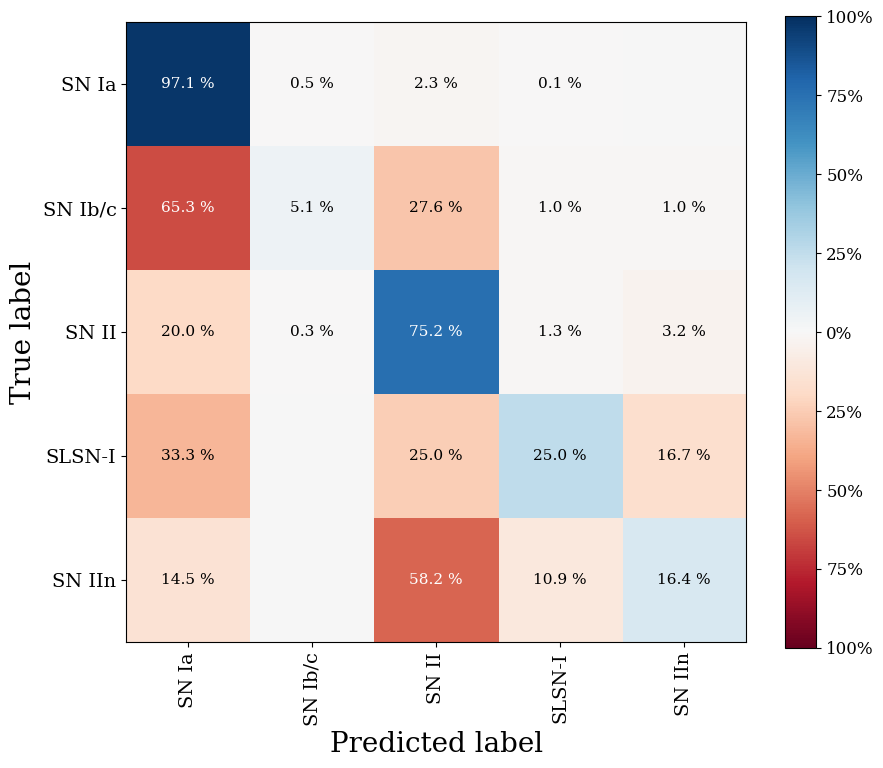

In [12]:
plot = plot_cm(cm, leaves)

In [15]:
cm

array([[1326,    7,   31,    2,    0],
       [  64,    5,   27,    1,    1],
       [  62,    1,  233,    4,   10],
       [  12,    0,    9,    9,    6],
       [   8,    0,   32,    6,    9]])

In [14]:
from sklearn.metrics import classification_report

cr = (classification_report(
    fiveleaf_labels_test[gind], my_predicted_types[gind], 
    target_names=leaves))

print(cr)

              precision    recall  f1-score   support

       SN Ia       0.41      0.25      0.31        36
     SN Ib/c       0.70      0.75      0.73       310
       SN II       0.35      0.16      0.22        55
      SLSN-I       0.90      0.97      0.93      1366
      SN IIn       0.38      0.05      0.09        98

    accuracy                           0.85      1865
   macro avg       0.55      0.44      0.46      1865
weighted avg       0.81      0.85      0.82      1865



# Note this does not use heir-loss from here on 

1865


/tmp/ipykernel_63187/1292131547.py:4: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]
/tmp/ipykernel_63187/1292131547.py:11: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  gind = np.where(np.in1d(labels_train,leaves))[0]
/tmp/ipykernel_63187/1292131547.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  new_baseline_ytrain[:,i] = baseline_ytrain[:,j]
/tmp/ipykernel_63187/1292131547.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  new_baseline_ytest[:,i] = baseline_ytest[:,j]
/tmp/ipykernel_63187/1292131547.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detac

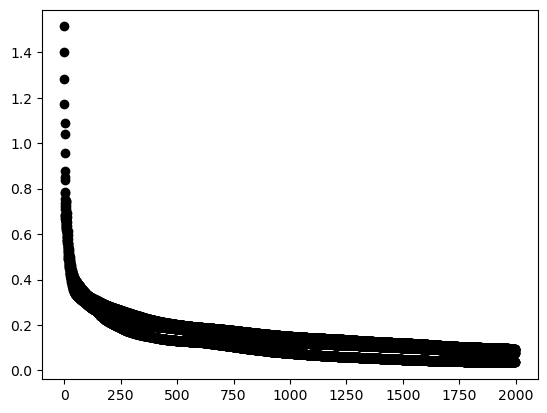

In [17]:
# Now for the same training/test set...train a baseline
# Train!

gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]
baseline_Xtest = X_test[gind]
baseline_ytest = y_test[gind]
baseline_labels_test = fiveleaf_labels_test[gind]

print(len(gind))

gind = np.where(np.in1d(labels_train,leaves))[0]
baseline_Xtrain = X_train[gind]
baseline_ytrain = y_train[gind]
baseline_labels_train = labels_train[gind]

# Now only keep relevant columns...

new_baseline_ytest = np.zeros((len(baseline_ytest), len(leaves)))
new_baseline_ytrain = np.zeros((len(baseline_ytrain), len(leaves)))

for i,leaf in enumerate(leaves):
    j = np.where(leaf == vertices)[0][0]
    new_baseline_ytrain[:,i] = baseline_ytrain[:,j]
    new_baseline_ytest[:,i] = baseline_ytest[:,j]

baseline_ytrain = torch.tensor(new_baseline_ytrain)
baseline_ytest = torch.tensor(baseline_ytest)

model_baseline = hxetda.Feedforward(np.shape(X_test[0])[0],15, len(leaves))
optimizer = torch.optim.AdamW(model_baseline.parameters(), lr = 0.01)
model_baseline.train()
epoch = 2000
n_batches = 1024


#class_weights=class_weight.compute_class_weight('balanced',classes=np.unique(labels_test),y=my_predicted_types)

myloss = torch.nn.CrossEntropyLoss()

for epoch in range(epoch):
	for i in range(int(len(baseline_Xtrain)/n_batches)+1):
		# Local batches and labels
		local_X, local_y = baseline_Xtrain[i*n_batches:(i+1)*n_batches,], baseline_ytrain[i*n_batches:(i+1)*n_batches,]
		optimizer.zero_grad()
		# Forward pass
		y_pred_baseline = model_baseline(local_X)
		# Compute Loss
		loss = myloss(y_pred_baseline,local_y)
		# Backward pass
		loss.backward()
		optimizer.step()
		plt.plot(epoch,loss.detach().numpy(),'ko')
	#scheduler.step()
plt.show()

(0.5117595133773092, 0.4150818152736364, 0.41403710027658625, None)
(0.8278820375335121, 0.8278820375335121, 0.8278820375335121, None)


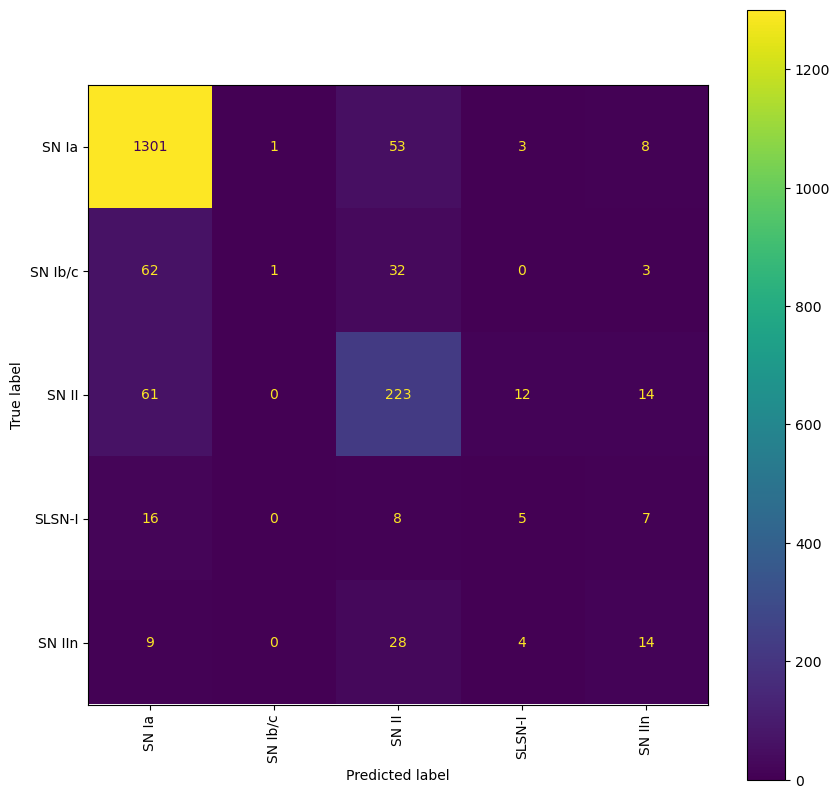

In [18]:
model_baseline.eval()
y_pred_baseline = model_baseline(baseline_Xtest).detach().numpy()
predicted_baseline_types = leaves[np.argmax(y_pred_baseline,axis=1)]
cm = confusion_matrix(baseline_labels_test, predicted_baseline_types, labels=leaves)
disp = ConfusionMatrixDisplay(cm, display_labels=leaves)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(xticks_rotation='vertical', ax=ax)
plt.title("Baseline Model")

print(precision_recall_fscore_support(baseline_labels_test, predicted_baseline_types,average='macro'))
print(precision_recall_fscore_support(baseline_labels_test, predicted_baseline_types,average='micro'))

# Sibling task

In [ ]:
importlib.reload(hxetda)

siblings = np.asarray(['StellarTransient', 'SN-like'])
probs_list = np.zeros((len(y_pred), len(siblings)))
for i,sib in enumerate(siblings):
    probs_list[:,i] = hxetda.get_prob(y_pred,sib, paths, vertices, mask_list).detach().numpy()

my_predicted_types = siblings[np.argmax(probs_list,axis=1)]

sibling_labels_test = np.copy(labels_test)
for i,s in enumerate(sibling_labels_test):
    is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

    if is_StellarTransient:
        sibling_labels_test[i] = 'StellarTransient'
    else:
        sibling_labels_test[i] = 'SN-like'


cm = confusion_matrix(sibling_labels_test, my_predicted_types, labels=siblings)
disp = ConfusionMatrixDisplay(cm, display_labels=siblings)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(xticks_rotation='vertical', ax=ax)

print(precision_recall_fscore_support(sibling_labels_test, my_predicted_types,average='macro'))
print(precision_recall_fscore_support(sibling_labels_test, my_predicted_types,average='micro'))

In [ ]:
# And now baseline...
# Now for the same training/test set...train a baseline
# Train!

siblings = np.asarray(['StellarTransient', 'SN-like'])

baseline_ytest = np.zeros((len(y_test), len(siblings)))
sibling_labels_test = np.copy(labels_test)
for i,s in enumerate(sibling_labels_test):
    is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

    if is_StellarTransient:
        sibling_labels_test[i] = 'StellarTransient'
        baseline_ytest[i,0] = 1

    else:
        sibling_labels_test[i] = 'SN-like'
        baseline_ytest[i,1] = 1



baseline_ytrain = np.zeros((len(y_train), len(siblings)))
sibling_labels_train = np.copy(labels_train)
for i,s in enumerate(sibling_labels_train):
    is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

    if is_StellarTransient:
        sibling_labels_train[i] = 'StellarTransient'
        baseline_ytrain[i,0] = 1

    else:
        sibling_labels_train[i] = 'SN-like'
        baseline_ytrain[i,1] = 1


baseline_ytrain = torch.tensor(baseline_ytrain)
baseline_ytest = torch.tensor(baseline_ytest)

model_baseline = hxetda.Feedforward(np.shape(X_test[0])[0],15, len(siblings))
optimizer = torch.optim.AdamW(model_baseline.parameters(), lr = 0.05)
model_baseline.train()
epoch = 1000
n_batches = 1024

baseline_Xtrain = torch.tensor(np.copy(X_train))
baseline_Xtest = torch.tensor(np.copy(X_test))

myloss = torch.nn.CrossEntropyLoss()

for epoch in range(epoch):
	for i in range(int(len(baseline_Xtrain)/n_batches)+1):
		# Local batches and labels
		local_X, local_y = baseline_Xtrain[i*n_batches:(i+1)*n_batches,], baseline_ytrain[i*n_batches:(i+1)*n_batches,]
		optimizer.zero_grad()
		# Forward pass
		y_pred_baseline = model_baseline(local_X)
		# Compute Loss
		loss = myloss(y_pred_baseline,local_y)
		# Backward pass
		loss.backward()
		optimizer.step()
		plt.plot(epoch,loss.detach().numpy(),'ko')
plt.show()

In [ ]:
model_baseline.eval()
y_pred_baseline = model_baseline(baseline_Xtest).detach().numpy()
predicted_baseline_types = siblings[np.argmax(y_pred_baseline,axis=1)]
cm = confusion_matrix(sibling_labels_test, predicted_baseline_types, labels=siblings)
disp = ConfusionMatrixDisplay(cm, display_labels=siblings)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(xticks_rotation='vertical', ax=ax)

print(precision_recall_fscore_support(sibling_labels_test, predicted_baseline_types,average='macro'))
print(precision_recall_fscore_support(sibling_labels_test, predicted_baseline_types,average='micro'))